In [ ]:
import ydf
import pandas as pd
import numpy as np

In [3]:
def split_dataset(ds, test_ratio):
  test_indices = np.random.rand(len(ds)) < test_ratio
  return ds[~test_indices], ds[test_indices]

crime_dataset = pd.read_csv("./Crime_Data_from_2020_to_2024.csv")
crime_dataset = crime_dataset.drop(columns = ["Status Desc"])
crime_train, crime_test = split_dataset(crime_dataset, 0.10)
print(len(crime_train), len(crime_test))

904550 100344


In [4]:
print(pd.unique(crime_dataset.Status))
crime_clean = crime_dataset.dropna(subset = ["Status"])
print(np.unique(crime_clean.Status.astype(str)))

<StringArray>
['IC', 'AO', 'AA', 'JA', 'JO', 'CC', nan]
Length: 7, dtype: str
['AA' 'AO' 'CC' 'IC' 'JA' 'JO']


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
counts = crime_clean.Status.value_counts()
print(counts)

Status
IC    802772
AO    109799
AA     87152
JA      3285
JO      1879
CC         6
Name: count, dtype: int64


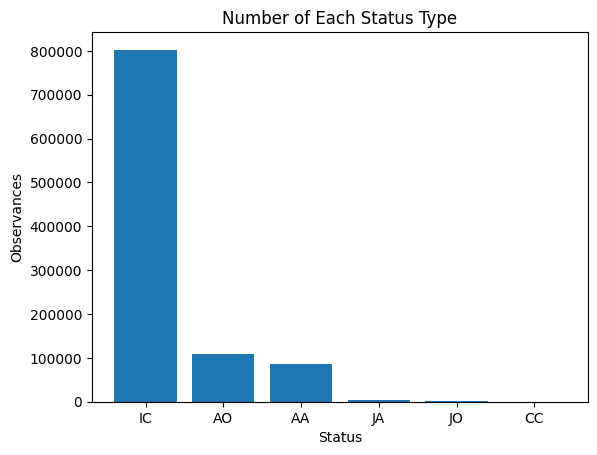

In [7]:
plt.bar(counts.index, counts.values)
plt.xlabel("Status")
plt.ylabel("Observances")
plt.title("Number of Each Status Type")
plt.show()

In [8]:
top_20 = crime_clean['Crm Cd'].value_counts().head(20).index
crime_clean_top20 = crime_clean[crime_clean['Crm Cd'].isin(top_20)]

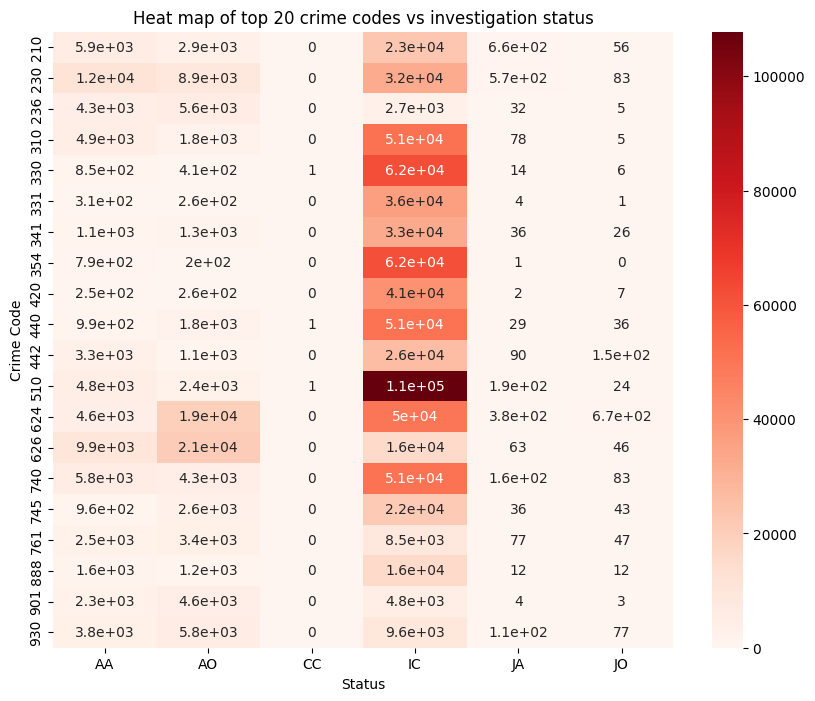

In [10]:

ct = pd.crosstab(crime_clean_top20['Crm Cd'], crime_clean_top20.Status)

plt.figure(figsize=(10,8))
sns.heatmap(ct, cmap="Reds", annot=True)
plt.xlabel("Status")
plt.ylabel("Crime Code")
plt.title("Heat map of top 20 crime codes vs investigation status")
plt.show()

DATE OCC
2020 Jan 01 12:00:00 AM    1164
2023 Jan 01 12:00:00 AM    1159
2022 Dec 02 12:00:00 AM    1132
2023 Feb 01 12:00:00 AM    1093
2022 Oct 01 12:00:00 AM    1079
2022 Dec 01 12:00:00 AM    1056
2022 Jun 01 12:00:00 AM    1048
2022 Sep 01 12:00:00 AM    1039
2023 Feb 02 12:00:00 AM    1038
2022 Apr 01 12:00:00 AM    1033
2022 Jul 01 12:00:00 AM    1031
2022 Jan 01 12:00:00 AM    1022
2022 Nov 01 12:00:00 AM    1006
2022 Aug 01 12:00:00 AM    1002
2022 May 01 12:00:00 AM    1000
2023 Feb 03 12:00:00 AM    1000
2021 Jan 01 12:00:00 AM     970
2022 Feb 01 12:00:00 AM     970
2022 Mar 01 12:00:00 AM     968
2022 May 02 12:00:00 AM     966
Name: count, dtype: int64


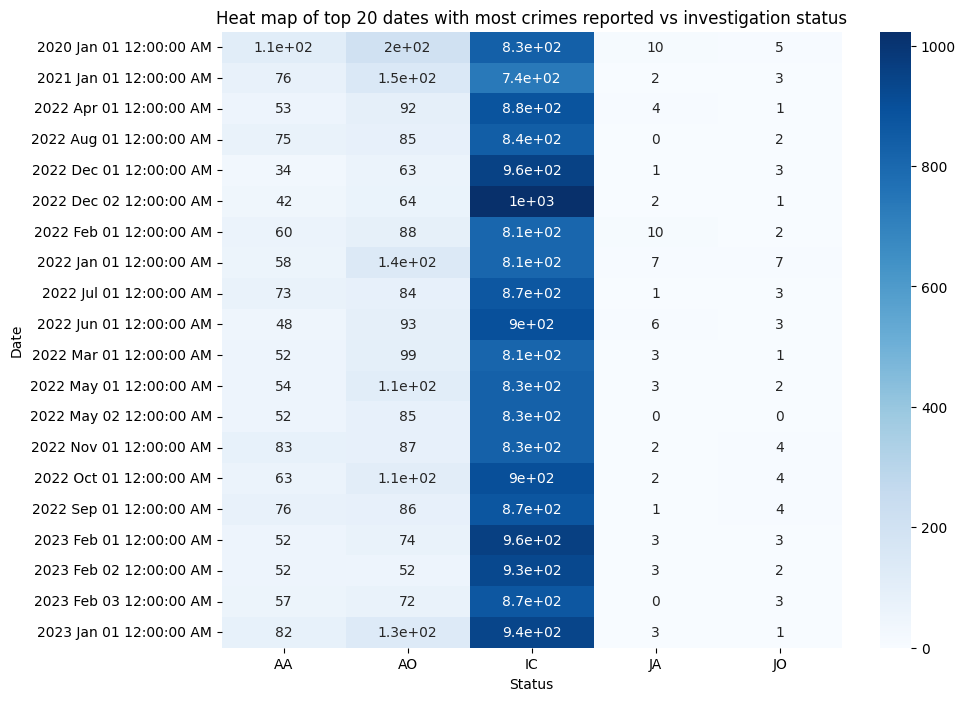

In [11]:
top_20_date = crime_clean['DATE OCC'].value_counts().head(20).index
crime_clean_top20_date = crime_clean[crime_clean['DATE OCC'].isin(top_20_date)]
date_count = crime_clean['DATE OCC'].value_counts().head(20)
print(date_count)

ct = pd.crosstab(crime_clean_top20_date['DATE OCC'], crime_clean_top20_date.Status)
plt.figure(figsize=(10,8))
sns.heatmap(ct, cmap="Blues", annot=True)
plt.xlabel("Status")
plt.ylabel("Date")
plt.title("Heat map of top 20 dates with most crimes reported vs investigation status")
plt.show()

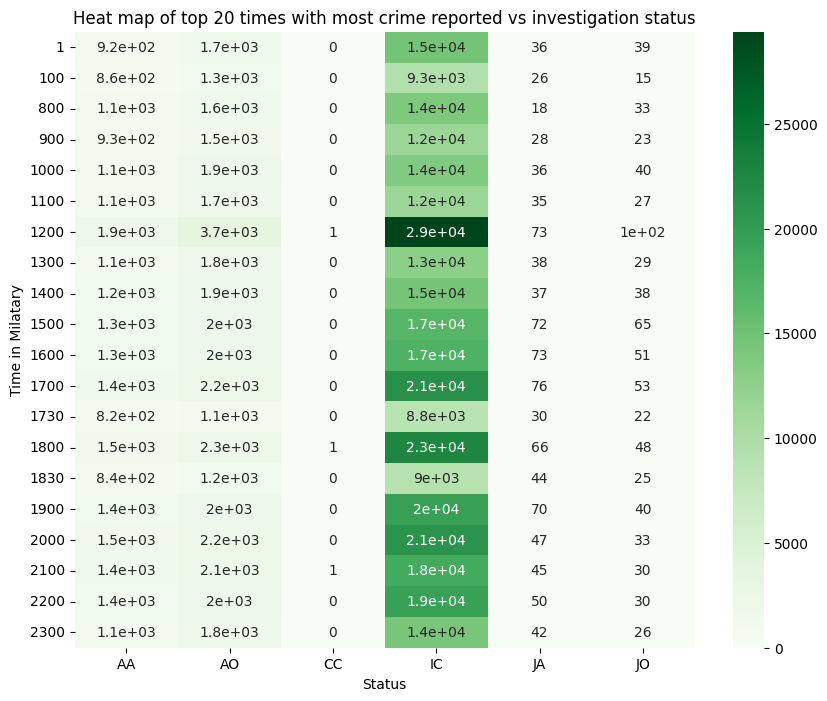

In [12]:
top_20_time = crime_clean['TIME OCC'].value_counts().head(20).index
crime_clean_top20_time = crime_clean[crime_clean['TIME OCC'].isin(top_20_time)]
ct = pd.crosstab(crime_clean_top20_time['TIME OCC'], crime_clean_top20_time.Status)
plt.figure(figsize=(10,8))
sns.heatmap(ct, cmap="Greens", annot=True)
plt.xlabel("Status")
plt.ylabel("Time in Milatary")
plt.title("Heat map of top 20 times with most crime reported vs investigation status")
plt.show()

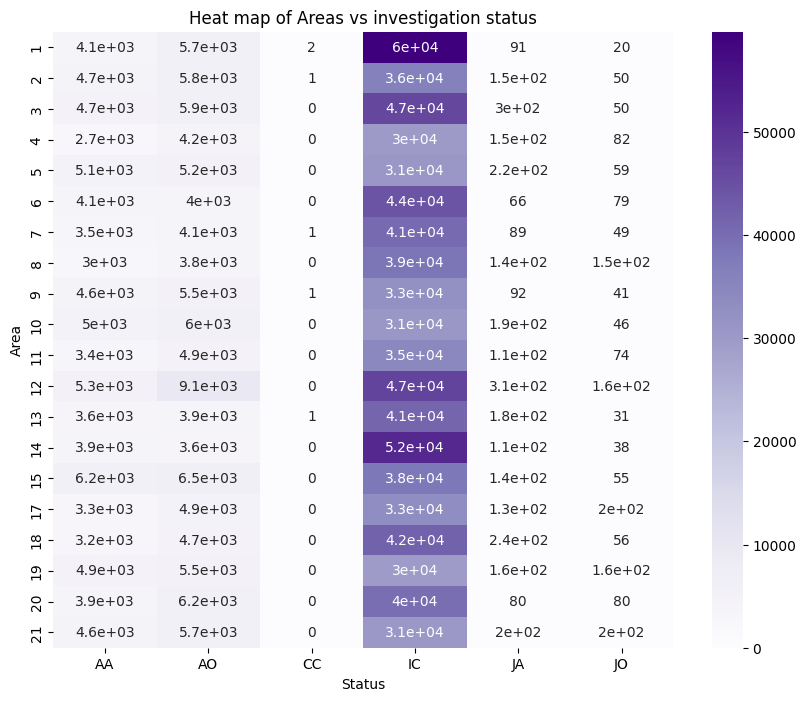

In [13]:
top_20_area = crime_clean.AREA.value_counts().head(20).index
crime_clean_top20_area = crime_clean[crime_clean['AREA'].isin(top_20_area)]
ct = pd.crosstab(crime_clean_top20_area.AREA, crime_clean_top20_area.Status)
plt.figure(figsize=(10,8))
sns.heatmap(ct, cmap="Purples", annot=True)
plt.xlabel("Status")
plt.ylabel("Area")
plt.title("Heat map of Areas vs investigation status")
plt.show()


In [28]:
crime_IC = crime_train[crime_train["Status"] == "IC"]
crime_CC = crime_train[crime_train["Status"] == "CC"]
crime_AA = crime_train[crime_train["Status"] == "AA"]
crime_AO = crime_train[crime_train["Status"] == "AO"]
crime_JA = crime_train[crime_train["Status"] == "JA"]
crime_JO = crime_train[crime_train["Status"] == "JO"]

In [29]:
len(crime_IC), len(crime_CC), len(crime_AA), len(crime_AO), len(crime_JA), len(crime_JO)

(722600, 4, 78299, 98709, 2986, 1685)

In [30]:


crime_IC_keep, crime_IC_toss = split_dataset(crime_IC, 0.889) # keep 1/9th of ICs
crime_AO_keep, crime_AO_toss = split_dataset(crime_AO, 0.2) # keep 4/5ths of AO
crime_JA_dup = pd.concat([crime_JA]*27) # repeat JA 27 times
crime_JO_dup = pd.concat([crime_JO]*48) # repeat JO 48 times

len(crime_IC_keep), len(crime_AA), len(crime_AO_keep), len(crime_JA_dup), len(crime_JO_dup)

(80362, 78299, 78940, 80622, 80880)

In [31]:
crime_resample = pd.concat([crime_IC_keep, crime_AA, crime_AO_keep, crime_JA_dup, crime_JO_dup])
crime_resample = crime_resample.sample(frac = 1).reset_index(drop=True) # reshuffle
crime_resample.head(20)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Weapon Desc,Status,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,232109906,2023 Jun 03 12:00:00 AM,2023 Jun 01 12:00:00 AM,1600,21,Topanga,2196,2,930,CRIMINAL THREATS - NO WEAPON DISPLAYED,...,VERBAL THREAT,AA,930.0,NaN,NaN,NaN,4300 SALTILLO ST,NaN,34.1478,-118.5934
1,220813871,2022 Aug 29 12:00:00 AM,2022 Aug 24 12:00:00 AM,1550,8,West LA,889,2,813,CHILD ANNOYING (17YRS & UNDER),...,NaN,IC,813.0,NaN,NaN,NaN,CORNING,CADILLAC,34.0392,-118.3807
2,221412494,2022 Jun 16 12:00:00 AM,2022 Jun 14 12:00:00 AM,1030,14,Pacific,1413,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,626.0,NaN,NaN,NaN,200 3RD AV,NaN,33.9985,-118.4776
3,200308263,2020 Mar 09 12:00:00 AM,2020 Mar 09 12:00:00 AM,1000,3,Southwest,363,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,626.0,NaN,NaN,NaN,4000 ABOURNE RD,NaN,34.0103,-118.3456
4,221315894,2022 Aug 12 12:00:00 AM,2022 Aug 12 12:00:00 AM,530,13,Newton,1307,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,NaN,IC,341.0,NaN,NaN,NaN,7TH ST,SAN PEDRO,34.0401,-118.2459
5,230505752,2023 Feb 17 12:00:00 AM,2023 Feb 17 12:00:00 AM,1615,5,Harbor,515,1,433,DRIVING WITHOUT OWNER CONSENT (DWOC),...,NaN,JA,433.0,NaN,NaN,NaN,100 W PACIFIC COAST HY,NaN,33.7948,-118.2694
6,231218166,2023 Aug 22 12:00:00 AM,2023 Aug 22 12:00:00 AM,1100,12,77th Street,1269,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,626.0,NaN,NaN,NaN,80TH ST,AVALON BL,33.9665,-118.2652
7,202104733,2020 Jan 16 12:00:00 AM,2020 Jan 16 12:00:00 AM,1910,21,Topanga,2158,1,442,SHOPLIFTING - PETTY THEFT ($950 & UNDER),...,NaN,AA,442.0,NaN,NaN,NaN,6300 VARIEL AV,NaN,34.1847,-118.5928
8,210515818,2021 Nov 08 12:00:00 AM,2021 Nov 07 12:00:00 AM,100,5,Harbor,521,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,626.0,NaN,NaN,NaN,1400 W F ST,NaN,33.7763,-118.2817
9,211609219,2021 Jun 30 12:00:00 AM,2021 Jun 30 12:00:00 AM,2200,16,Foothill,1623,1,761,BRANDISH WEAPON,...,HAND GUN,JO,761.0,NaN,NaN,NaN,12900 CARL PL,NaN,34.2668,-118.4146


In [32]:
crime_resample.value_counts("Status")

,count
Status,
JO,80880
JA,80622
IC,80362
AO,78940
AA,78299


In [33]:
crime_final_train, _ = split_dataset(crime_resample, 0.93) # pare down for testing
crime_final_test, _ = split_dataset(crime_test, 0.93)
print(len(crime_final_train), len(crime_final_test))

28198 7123


In [34]:
model = ydf.RandomForestLearner(label = "Status", num_trees = 80).train(crime_final_train)

Train model on 28198 examples
Model trained in 0:11:07.121535


In [36]:
model.evaluate(crime_final_test)

Label \ Pred,AA,AO,IC,JA,JO
AA,214,218,112,76,11
AO,129,519,93,44,21
IC,712,870,3726,230,121
JA,1,2,1,9,3
JO,0,2,1,1,7
